In [1]:
import os
import json
os.chdir("../")
print("Current work path:", os.getcwd())

Current work path: /home/pengxy2024/ICLR2026


In [2]:
from src.algorithms.main import main
import os
import yaml

# dist 0: [[0.3, [0.8, 0.2]], [0.7, [0.2, 0.8]]]

def load_config(config_path):
    # Check if the config file exists
    if not os.path.exists(config_path):
        raise FileNotFoundError(f"Configuration file not found: {config_path}")
    # Load the configuration from the YAML file
    with open(config_path, "r") as file:
        config = yaml.safe_load(file)
    return config

seeds = [42, 57, 89, 137, 798]
# seeds = [42, 57]

In [3]:
# ours method
our_results = {}
config = load_config("src/configs/god_AUPD_routerbench_2stages.yaml")

for seed in seeds:
    new_config = config.copy()
    new_config["seed"] = seed
    new_config["project_name"] = f"{config['project_name']}_seed{seed}"
    log_path = os.path.join(config["log_dir"], new_config["project_name"])
    if os.path.exists(log_path):
        print(f"Skipping seed {seed} as log path already exists: {log_path}")
        our_results[seed] = json.load(open(os.path.join(log_path, "history.json"), "r"))
    else:
        our_results[seed] = main(new_config)

Skipping seed 42 as log path already exists: outputs/routerbench_2stage_logs_dist1_final/god_expAUPD_seed42
Skipping seed 57 as log path already exists: outputs/routerbench_2stage_logs_dist1_final/god_expAUPD_seed57
Skipping seed 89 as log path already exists: outputs/routerbench_2stage_logs_dist1_final/god_expAUPD_seed89
Skipping seed 137 as log path already exists: outputs/routerbench_2stage_logs_dist1_final/god_expAUPD_seed137
Skipping seed 798 as log path already exists: outputs/routerbench_2stage_logs_dist1_final/god_expAUPD_seed798


In [4]:
# google method
best_lambdas = [0.001, 0.37] 

google_results = {}
config = load_config("src/configs/god_google_routerbench_2stages.yaml")

for seed in seeds:
    for lambda_val in best_lambdas:
        new_config = config.copy()
        new_config["seed"] = seed
        new_config["project_name"] = f"{config['project_name']}_seed{seed}_lambda{lambda_val}"
        new_config["agent"]["lambda"] = lambda_val
        log_path = os.path.join(config["log_dir"], new_config["project_name"])
        if os.path.exists(log_path):
            print(f"Skipping seed {seed} and lambda {lambda_val} as log path already exists: {log_path}")
            google_results[(seed, lambda_val)] = json.load(open(os.path.join(log_path, "history.json"), "r"))
        else:
            google_results[(seed, lambda_val)] = main(new_config)

Skipping seed 42 and lambda 0.001 as log path already exists: outputs/routerbench_2stage_logs_dist1_final/god_google_seed42_lambda0.001
Skipping seed 42 and lambda 0.37 as log path already exists: outputs/routerbench_2stage_logs_dist1_final/god_google_seed42_lambda0.37
Skipping seed 57 and lambda 0.001 as log path already exists: outputs/routerbench_2stage_logs_dist1_final/god_google_seed57_lambda0.001
Skipping seed 57 and lambda 0.37 as log path already exists: outputs/routerbench_2stage_logs_dist1_final/god_google_seed57_lambda0.37
Skipping seed 89 and lambda 0.001 as log path already exists: outputs/routerbench_2stage_logs_dist1_final/god_google_seed89_lambda0.001
Skipping seed 89 and lambda 0.37 as log path already exists: outputs/routerbench_2stage_logs_dist1_final/god_google_seed89_lambda0.37
Skipping seed 137 and lambda 0.001 as log path already exists: outputs/routerbench_2stage_logs_dist1_final/god_google_seed137_lambda0.001
Skipping seed 137 and lambda 0.37 as log path alread

In [5]:
def get_budget(costs, B):
    ret = {}
    for seed in seeds:
        ret_b = []
        budget = B
        for cost in costs[seed]:
            if budget - cost >= 0:
                budget -= cost
                ret_b.append(budget / 1000)
            else:
                ret_b.append(budget / 1000)
                budget = 0
        ret[seed] = ret_b
    return ret

def get_smooth_rewards(rewards):
    ret = {}
    for seed in seeds:
        smooth_rewards = []
        totla_reward = 0
        num = 0
        for reward in rewards[seed]:
            totla_reward += reward
            num += 1
            smooth_rewards.append(totla_reward / num)
        ret[seed] = smooth_rewards
    return ret

In [6]:

B = 20000
ours_rewards = {seed: [data["reward"] for data in our_results[seed]] for seed in seeds}
ours_costs = {seed: [data["cost"] for data in our_results[seed]] for seed in seeds}
ours_budget = get_budget(ours_costs, B) 
ours_rewards = get_smooth_rewards(ours_rewards)

lambda0_reward = {seed: [data["reward"] for data in google_results[(seed, best_lambdas[0])]] for seed in seeds}
lambda0_cost = {seed: [data["cost"] for data in google_results[(seed, best_lambdas[0])]] for seed in seeds}
lambda0_budget = get_budget(lambda0_cost, B) 
lambda0_reward = get_smooth_rewards(lambda0_reward)

lambda1_reward = {seed: [data["reward"] for data in google_results[(seed, best_lambdas[1])]] for seed in seeds}
lambda1_cost = {seed: [data["cost"] for data in google_results[(seed, best_lambdas[1])]] for seed in seeds}
lambda1_budget = get_budget(lambda1_cost, B) 
lambda1_reward = get_smooth_rewards(lambda1_reward)


In [7]:
def general_beautify(ax):
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.spines['bottom'].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.spines['left'].set_linewidth(0.5)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.set_facecolor('white')
    ax.margins(0.02)


colorset = [[84 / 255, 111 / 255, 198 / 255],  
            [145 / 255, 203 / 255, 116 / 255], 
            [250 / 255, 200 / 255, 89 / 255], 
            [238 / 255, 102 / 255, 102 / 255],
            [115 / 255, 192 / 255, 222 / 255],
            [59 / 255, 163 / 255, 114 / 255], 
            [252 / 255, 132 / 255, 82 / 255], 
            [154 / 255, 96 / 255, 180 / 255], 
            # [142 / 255, 51 / 255, 138 / 255],
            ]

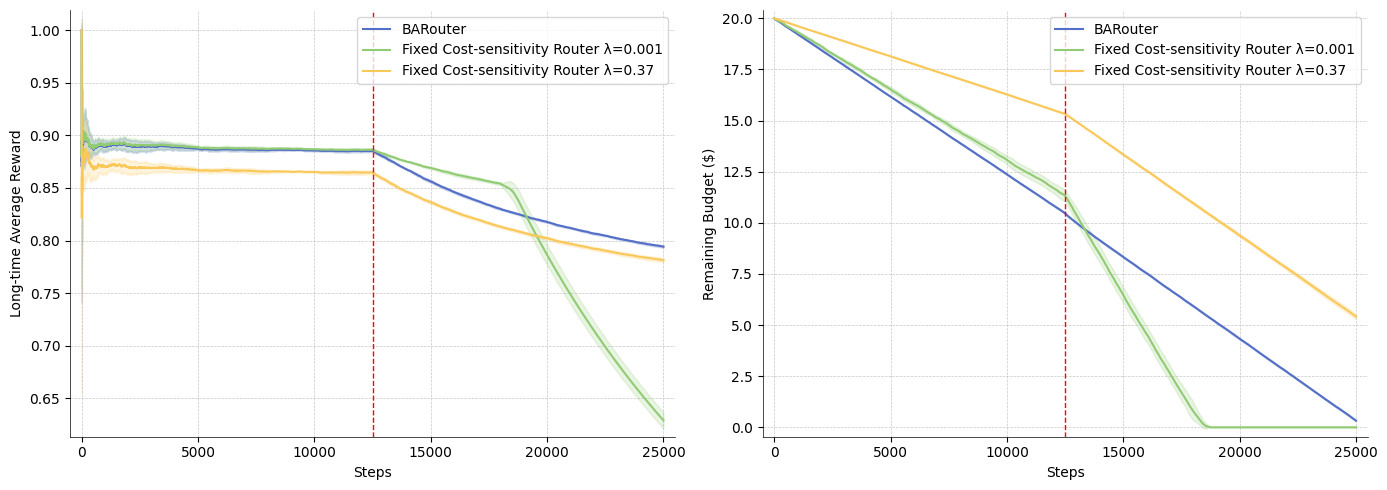

In [ ]:
# 画图
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
for ax in axs:
    general_beautify(ax)

# Plot rewards
avg_ours_rewards = [sum(ours_rewards[seed][i] for seed in seeds) / len(seeds) for i in range(len(ours_rewards[seeds[0]]))]
avg_lambda0_rewards = [sum(lambda0_reward[seed][i] for seed in seeds) / len(seeds) for i in range(len(lambda0_reward[seeds[0]]))]
avg_lambda1_rewards = [sum(lambda1_reward[seed][i] for seed in seeds) / len(seeds) for i in range(len(lambda1_reward[seeds[0]]))]

std_ours_rewards = [ (sum((ours_rewards[seed][i] - avg_ours_rewards[i])**2 for seed in seeds) / len(seeds))**0.5 for i in range(len(ours_rewards[seeds[0]]))]
std_lambda0_rewards = [ (sum((lambda0_reward[seed][i] - avg_lambda0_rewards[i])**2 for seed in seeds) / len(seeds))**0.5 for i in range(len(lambda0_reward[seeds[0]]))]
std_lambda1_rewards = [ (sum((lambda1_reward[seed][i] - avg_lambda1_rewards[i])**2 for seed in seeds) / len(seeds))**0.5 for i in range(len(lambda1_reward[seeds[0]]))]

axs[0].plot(avg_ours_rewards, label='BARouter', color=colorset[0])
axs[0].fill_between(range(len(avg_ours_rewards)),
                    [avg_ours_rewards[i] - std_ours_rewards[i] for i in range(len(avg_ours_rewards))],
                    [avg_ours_rewards[i] + std_ours_rewards[i] for i in range(len(avg_ours_rewards))],
                    color=colorset[0], alpha=0.2)
axs[0].plot(avg_lambda0_rewards, label=f'Fixed Cost-sensitivity Router λ={best_lambdas[0]}', color=colorset[1])
axs[0].fill_between(range(len(avg_lambda0_rewards)),
                    [avg_lambda0_rewards[i] - std_lambda0_rewards[i] for i in range(len(avg_lambda0_rewards))],
                    [avg_lambda0_rewards[i] + std_lambda0_rewards[i] for i in range(len(avg_lambda0_rewards))],
                    color=colorset[1], alpha=0.2)
axs[0].plot(avg_lambda1_rewards, label=f'Fixed Cost-sensitivity Router λ={best_lambdas[1]}', color=colorset[2])
axs[0].fill_between(range(len(avg_lambda1_rewards)),
                    [avg_lambda1_rewards[i] - std_lambda1_rewards[i] for i in range(len(avg_lambda1_rewards))],
                    [avg_lambda1_rewards[i] + std_lambda1_rewards[i] for i in range(len(avg_lambda1_rewards))],
                    color=colorset[2], alpha=0.2)
axs[0].axvline(x=12500, color='red', linestyle='--', linewidth=1)
axs[0].set_xlabel('Steps')
axs[0].set_ylabel('Long-time Average Reward')
# axs[0].set_title('Average Reward vs Steps')
axs[0].legend()

avg_budget_ours = [sum(ours_budget[seed][i] for seed in seeds) / len(seeds) for i in range(len(ours_budget[seeds[0]]))]
avg_budget_lambda0 = [sum(lambda0_budget[seed][i] for seed in seeds) / len(seeds) for i in range(len(lambda0_budget[seeds[0]]))]
avg_budget_lambda1 = [sum(lambda1_budget[seed][i] for seed in seeds) / len(seeds) for i in range(len(lambda1_budget[seeds[0]]))]

std_budget_ours = [ (sum((ours_budget[seed][i] - avg_budget_ours[i])**2 for seed in seeds) / len(seeds))**0.5 for i in range(len(ours_budget[seeds[0]]))]
std_budget_lambda0 = [ (sum((lambda0_budget[seed][i] - avg_budget_lambda0[i])**2 for seed in seeds) / len(seeds))**0.5 for i in range(len(lambda0_budget[seeds[0]]))]
std_budget_lambda1 = [ (sum((lambda1_budget[seed][i] - avg_budget_lambda1[i])**2 for seed in seeds) / len(seeds))**0.5 for i in range(len(lambda1_budget[seeds[0]]))]

axs[1].plot(avg_budget_ours, label='BARouter', color=colorset[0])
axs[1].plot(avg_budget_lambda0, label=f'Fixed Cost-sensitivity Router λ={best_lambdas[0]}', color=colorset[1])
axs[1].plot(avg_budget_lambda1, label   =f'Fixed Cost-sensitivity Router λ={best_lambdas[1]}', color=colorset[2])
axs[1].fill_between(range(len(avg_budget_ours)),
                    [avg_budget_ours[i] - std_budget_ours[i] for i in range(len(avg_budget_ours))],
                    [avg_budget_ours[i] + std_budget_ours[i] for i in range(len(avg_budget_ours))],
                    color=colorset[0], alpha=0.2)
axs[1].fill_between(range(len(avg_budget_lambda0)),
                    [avg_budget_lambda0[i] - std_budget_lambda0[i] for i in range(len(avg_budget_lambda0))],
                    [avg_budget_lambda0[i] + std_budget_lambda0[i] for i in range(len(avg_budget_lambda0))],
                    color=colorset[1], alpha=0.2)
axs[1].fill_between(range(len(avg_budget_lambda1)),
                    [avg_budget_lambda1[i] - std_budget_lambda1[i] for i in range(len(avg_budget_lambda1))],
                    [avg_budget_lambda1[i] + std_budget_lambda1[i] for i in range(len(avg_budget_lambda1))],
                    color=colorset[2], alpha=0.2)
axs[1].axvline(x=12500, color='red', linestyle='--', linewidth=1)
axs[1].set_xlabel('Steps')
axs[1].set_ylabel('Remaining Budget ($)')
# axs[1].set_title('Average Remaining Budget vs Steps')
axs[1].legend() 



plt.tight_layout()
plt.savefig('img/2stage_routerbench.pdf', format='pdf', bbox_inches='tight')
plt.show()